# Topics to be covered in this session:

1. How to create tensors?
2. Two ways of declaring tensors
3. Mathematical Operations
4. Linear Algebra

### Following topics are covered in the optional session titled: 'Advanced Operations with TensorFlow'

5. Reshaping and Broadcasting
6. Automatic Differentiation

### 1. Tensors of different ranks

In [1]:
import os
print(os.path.expanduser("~"))

C:\Users\kirth


In [2]:
# was not able to use pip install tensorflow so had to use below one

In [3]:
# import sys
# !{sys.executable} -m pip install tensorflow --user

In [4]:
import tensorflow as tf
import numpy as np

In [5]:
"""A vector is a 1-dimensional tensor"""

# Vector in TensorFlow
vector_tf = tf.constant([0, 1, 2, 3, 4])

# Vector in Numpy
vector_np = np.array([0, 1, 2, 3, 4])

print("Shapes:", vector_tf.shape, vector_np.shape)

""" A matrix is a 2-dimensional tensor"""

# Matrix in TensorFlow
matrix_tf = tf.constant([[0, 1], [2, 3], [4, 5]])

# Matrix in Numpy
matrix_np = np.array([[0, 1], [2, 3], [4, 5]])

print("Shapes:", matrix_tf.shape, matrix_np.shape)

"""3-dimensional tensor"""

# 3-d tensor in TensorFlow
t3_tf = tf.constant([[[0., 1.], [2, 3], [4, 5]]]*5)

# 3-d matrix in Numpy
t3_np = np.array([[[0, 1], [2, 3], [4, 5]]]*5)

print("Shapes:", t3_tf.shape, t3_np.shape)

Shapes: (5,) (5,)
Shapes: (3, 2) (3, 2)
Shapes: (5, 3, 2) (5, 3, 2)


In [6]:
# 0. and 1.0 is there and even 2,3 we give float the datatype for all 
print(t3_tf)

tf.Tensor(
[[[0. 1.]
  [2. 3.]
  [4. 5.]]

 [[0. 1.]
  [2. 3.]
  [4. 5.]]

 [[0. 1.]
  [2. 3.]
  [4. 5.]]

 [[0. 1.]
  [2. 3.]
  [4. 5.]]

 [[0. 1.]
  [2. 3.]
  [4. 5.]]], shape=(5, 3, 2), dtype=float32)


##Question##

Declare a tensor of shape (2,2,2,2) with random numbers from normal distribution whose mean is 1 and the standard deviation is also 1.


In [7]:
# approach 1 - initialize the nd array in Numpy and then use that to initialize the tensor
arr = np.random.randn(2,2,2,2) # returns random numbers from standard normal distribution - mean = 0, std = 1
print(arr.shape)
print(arr)

arr = arr + 1 # adding 1 makes the random numbers from normal distribtuion which has mean = 1

# to change the standard deviation as well as multiply with the new standard deviation, std = 2.5
# arr = 2.5 * arr + 1

arr_tf = tf.constant(arr)
print(arr_tf)



(2, 2, 2, 2)
[[[[ 0.45547527 -0.03620941]
   [ 1.27320471 -1.43346238]]

  [[-0.67367748  0.81778361]
   [-0.65839995  0.10879581]]]


 [[[ 0.19813742  0.39901027]
   [ 1.42316991 -1.3428403 ]]

  [[-1.24157464  0.14594767]
   [ 0.48138885  1.37620742]]]]
tf.Tensor(
[[[[ 1.45547527  0.96379059]
   [ 2.27320471 -0.43346238]]

  [[ 0.32632252  1.81778361]
   [ 0.34160005  1.10879581]]]


 [[[ 1.19813742  1.39901027]
   [ 2.42316991 -0.3428403 ]]

  [[-0.24157464  1.14594767]
   [ 1.48138885  2.37620742]]]], shape=(2, 2, 2, 2), dtype=float64)


In [8]:
print(type(arr_tf.numpy()))

<class 'numpy.ndarray'>


In [9]:
# approach 2 - using random number genrating functions from TensorFlow
arr_tf = tf.random.normal((2,2,2,2), mean=1, stddev=1, name="my_tensor")
print(arr_tf.shape)
print(arr_tf.numpy())

(2, 2, 2, 2)
[[[[0.9299786  1.8246467 ]
   [0.2770905  2.3712163 ]]

  [[1.6277394  1.7975185 ]
   [1.0490901  2.337409  ]]]


 [[[0.648874   2.8389719 ]
   [1.6918032  1.7689863 ]]

  [[0.18606967 0.6581595 ]
   [1.6500092  1.6945646 ]]]]


In [10]:
arr_tf = tf.random.normal((2,2,2,2), mean=1, stddev=1, name="my_tensor")
print(arr_tf.shape)

(2, 2, 2, 2)


In [11]:
print(arr_tf.numpy())

[[[[ 0.66010976  0.20144206]
   [-1.1938114   1.1656736 ]]

  [[ 1.7954056   0.12424326]
   [-0.4181037   1.012072  ]]]


 [[[ 1.5885181  -0.99783826]
   [ 1.3054888   1.0573405 ]]

  [[ 1.803326    1.2715652 ]
   [-0.2974236   0.04228401]]]]


### 2. Two ways of declaring tensors

In [12]:
"""Two types of tensors: tf.constant & tf.Variable"""
const_tensor = tf.constant([[1, 2, 3], [4, 5, 6]])
var_tensor = tf.Variable([[1, 2, 3], [4, 5, 6]])

In [13]:
"""Declaring tensors with specific datatypes"""
int32_tensor = tf.Variable([[1, 2, 3], [4, 5, 6]], dtype=tf.int32) # specify int32 datatype
float32_tensor = tf.Variable([[1, 2, 3], [4, 5, 6]], dtype=tf.float32) # specify float32 datatype
bool_tensor = tf.Variable([True, False, False], dtype=tf.bool) # specify bool datatype.

print("Int32 tensor:", int32_tensor)
print("Float32 tensor:", float32_tensor)
print("Boolean tensor:", bool_tensor)

Int32 tensor: <tf.Variable 'Variable:0' shape=(2, 3) dtype=int32, numpy=
array([[1, 2, 3],
       [4, 5, 6]], dtype=int32)>
<tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>
Boolean tensor: <tf.Variable 'Variable:0' shape=(3,) dtype=bool, numpy=array([ True, False, False])>


In [14]:
int32_tensor

<tf.Variable 'Variable:0' shape=(2, 3) dtype=int32, numpy=
array([[1, 2, 3],
       [4, 5, 6]], dtype=int32)>

In [15]:
# extra info will get removed if we use numpy()
int32_tensor.numpy()

array([[1, 2, 3],
       [4, 5, 6]], dtype=int32)

#### Note that tf.Variable infers the datatype if it is not specified. Hence the bool tensor could have been declared as
#### bool_tensor = tf.Variable([True, False, False])
#### and the result would have been same.

### 3. Common mathematical operations on tensors

In [16]:
"""Let us define two tensors"""

x = tf.Variable([list(range(5))]*5) # 2D tensor of shape (5, 5)
y = tf.Variable([list(range(5, 10))]*5) # 2D tensor of shape (5, 5)

print("x:", x)
print("y:", y)

x: <tf.Variable 'Variable:0' shape=(5, 5) dtype=int32, numpy=
array([[0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4]], dtype=int32)>
y: <tf.Variable 'Variable:0' shape=(5, 5) dtype=int32, numpy=
array([[5, 6, 7, 8, 9],
       [5, 6, 7, 8, 9],
       [5, 6, 7, 8, 9],
       [5, 6, 7, 8, 9],
       [5, 6, 7, 8, 9]], dtype=int32)>


In [17]:
"""Simple mathematical operations two tensors"""
z = x + y # element-wise addition
print("z:", z)

w = x * y # element-wise multiplications
print("w:", w)

v = y / x # element-wise division does not raise exception for division by 0 as TensorFlow supports Inf and NaN types
print("v:", v)

z: tf.Tensor(
[[ 5  7  9 11 13]
 [ 5  7  9 11 13]
 [ 5  7  9 11 13]
 [ 5  7  9 11 13]
 [ 5  7  9 11 13]], shape=(5, 5), dtype=int32)
w: tf.Tensor(
[[ 0  6 14 24 36]
 [ 0  6 14 24 36]
 [ 0  6 14 24 36]
 [ 0  6 14 24 36]
 [ 0  6 14 24 36]], shape=(5, 5), dtype=int32)
v: tf.Tensor(
[[       inf 6.         3.5        2.66666667 2.25      ]
 [       inf 6.         3.5        2.66666667 2.25      ]
 [       inf 6.         3.5        2.66666667 2.25      ]
 [       inf 6.         3.5        2.66666667 2.25      ]
 [       inf 6.         3.5        2.66666667 2.25      ]], shape=(5, 5), dtype=float64)


#### Alternatively, use TensorFlow functions for the mathematical operations
#### z = tf.add(x, y)
#### w = tf.multiply(x, y)
#### v = tf.divide(y, x)

#### Note that element-wise operations does not work if tensors have different shapes or cannot be broadcasted

In [18]:
# transpose of tensors
y = tf.Variable([[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10, 11], [12, 13, 14]]) # shape is (5, 3)
z = tf.transpose(y) # shape is (3, 5)
print("Before transpose:", y)
print("After transpose:", z)

Before transpose: <tf.Variable 'Variable:0' shape=(5, 3) dtype=int32, numpy=
array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int32)>
After transpose: tf.Tensor(
[[ 0  3  6  9 12]
 [ 1  4  7 10 13]
 [ 2  5  8 11 14]], shape=(3, 5), dtype=int32)


###     
### 4. Linear algebra on tensors

In [19]:
# Matrix multiplication
x = tf.Variable([[0, 1, 2, 3, 4], [5, 6, 7, 8, 9], [10, 11, 12, 13, 14], [15, 16, 17, 18, 19], [20, 21, 22, 23, 24]])
y = tf.Variable([[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10, 11], [12, 13, 14]])

z = tf.linalg.matmul(x, y) # matrix multiplication between a (5, 5) and a (5, 3) tensor
print("z:", z)

z: tf.Tensor(
[[ 90 100 110]
 [240 275 310]
 [390 450 510]
 [540 625 710]
 [690 800 910]], shape=(5, 3), dtype=int32)


#### Note that tf.linalg.matmul raises exception if tensor shapes are incompatible for matrix multiplication

In [20]:
# Matrix inverse
try:
    x = tf.Variable([[2, 3], [2, 2]])
    xinv = tf.linalg.inv(x)
    print("Inverse of x:", xinv)
except Exception as e:
    print("Exception raised while performing tensor inverse:\n", str(e))

Exception raised while performing tensor inverse:
 Value for attr 'T' of int32 is not in the list of allowed values: double, float, half, complex64, complex128
	; NodeDef: {{node MatrixInverse}}; Op<name=MatrixInverse; signature=input:T -> output:T; attr=adjoint:bool,default=false; attr=T:type,allowed=[DT_DOUBLE, DT_FLOAT, DT_HALF, DT_COMPLEX64, DT_COMPLEX128]> [Op:MatrixInverse] name: 


#### The above exception occured because matrix inverse is allowed only for float datatypes (float16, float 32 etc.). The try-except block
#### is purposefully used to demonstrate this behaviour.

In [21]:
# Let us try after changing the datatype using tf.cast function
x = tf.cast(x, tf.float32)
xinv = tf.linalg.inv(x)
print("Inverse of x:", xinv)

Inverse of x: tf.Tensor(
[[-1.   1.5]
 [ 1.  -1. ]], shape=(2, 2), dtype=float32)


#### Note that if the matrix is not invertible tf.linalg.inv will raise an exception

In [22]:
# Eigen value decomposition
x = tf.Variable([[3, 2, 4], [2, 0, 2], [4, 2, 3]], dtype=tf.float32) # raises exception if datatype is not floatX
eigen_values, eigen_vectors = tf.linalg.eigh(x)
print("Eigen values:", eigen_values)
print("Eigen vectors:", eigen_vectors)

Eigen values: tf.Tensor([-1.0000004 -0.9999995  8.       ], shape=(3,), dtype=float32)
Eigen vectors: tf.Tensor(
[[-0.74535596  0.          0.66666675]
 [ 0.2981424  -0.8944272   0.33333328]
 [ 0.59628487  0.4472136   0.6666666 ]], shape=(3, 3), dtype=float32)


##Question##

Solve the following system of linear equations using TensorFlow:

x + y + z + w = 13

2x + 3y − w = −1

−3x + 4y + z + 2w = 10

x + 2y − z + w = 1

Ans: x = 2, y = 0, z = 6 , w = 5

In [23]:
coeff = tf.Variable([[1,1,1,1], [2,3,0,-1], [-3,4,1,2], [1,2,-1,1]], dtype=tf.float32) # W
print("Coeff:", coeff)

y = tf.Variable([[13], [-1], [10], [1]], dtype=tf.float32)
print("y:", y)

# x = inverse of coeff X y

inv_coeff = tf.linalg.inv(coeff)
print("Inverse of coeff:", inv_coeff)

x_solution = tf.matmul(inv_coeff, y)
print(x_solution)


Coeff: <tf.Variable 'Variable:0' shape=(4, 4) dtype=float32, numpy=
array([[ 1.,  1.,  1.,  1.],
       [ 2.,  3.,  0., -1.],
       [-3.,  4.,  1.,  2.],
       [ 1.,  2., -1.,  1.]], dtype=float32)>
<tf.Variable 'Variable:0' shape=(4, 1) dtype=float32, numpy=
array([[13.],
       [-1.],
       [10.],
       [ 1.]], dtype=float32)>
Inverse of coeff: tf.Tensor(
[[ 2.77777791e-01  5.55555224e-02 -1.66666672e-01  1.11111104e-01]
 [-7.40740746e-02  1.85185164e-01  1.11111104e-01  3.70370336e-02]
 [ 4.62962925e-01  9.25926119e-02  5.55555634e-02 -4.81481493e-01]
 [ 3.33333343e-01 -3.33333343e-01 -9.93410776e-09  3.33333343e-01]], shape=(4, 4), dtype=float32)
tf.Tensor(
[[ 2.0000000e+00]
 [-1.1920929e-07]
 [ 5.9999995e+00]
 [ 5.0000000e+00]], shape=(4, 1), dtype=float32)


####**The following topics have been covered in the optional session : 'Advanced Operations with Tensorflow.'**

### 5. Reshaping and Broadcasting

#### 5.1. Reshaping

In [24]:
# Reshaping changes the dimensions or axes and assigns the cell values in proper locations in the new tensor
x = tf.Variable([[-3, 2, 4], [2, 0, -2], [5, 2, 3]], dtype=tf.float32)
print("Initial tensor:", x)
x_reshaped = tf.reshape(x, shape=(9, 1)) # a (3, 3) tensor can be reshaped to (9, 1) amd (1, 9) tensors only
print("Reshaped tensor:", x_reshaped)

Initial tensor: <tf.Variable 'Variable:0' shape=(3, 3) dtype=float32, numpy=
array([[-3.,  2.,  4.],
       [ 2.,  0., -2.],
       [ 5.,  2.,  3.]], dtype=float32)>
Reshaped tensor: tf.Tensor(
[[-3.]
 [ 2.]
 [ 4.]
 [ 2.]
 [ 0.]
 [-2.]
 [ 5.]
 [ 2.]
 [ 3.]], shape=(9, 1), dtype=float32)


In [25]:
# tf.reshape raises exception if the new shape is incompatible
try:
    x_reshape = tf.reshape(x, shape=(3, 4))
except Exception as e:
    print("Exception raised while reshaping:\n", str(e))

Exception raised while reshaping:
 {{function_node __wrapped__Reshape_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input to reshape is a tensor with 9 values, but the requested shape has 12 [Op:Reshape]


#### 5.2. Broadcasting

##### Mathematical operations on tensors requires shape compatibility otherwise exception is raised. However, broadcasting can resolve shape incompatibilities in few situations. Let us see an example.

In [26]:
x = tf.Variable([[3, 2, 4], [2, 0, 2], [4, 2, 3]], dtype=tf.float32)
k = tf.Variable([2.1])

print("Shape of x:", x.shape)
print("Shape of k:", k.shape)

# element-wise multiplication by broadcasting which repeats the only element in k along both the axes
# to resolve the shape imcompatibility
y = x * k
print("Shape of y:", y)

Shape of x: (3, 3)
Shape of k: (1,)
Shape of y: tf.Tensor(
[[6.2999997 4.2       8.4      ]
 [4.2       0.        4.2      ]
 [8.4       4.2       6.2999997]], shape=(3, 3), dtype=float32)


In [27]:
# Let us see another example
k = tf.Variable([2.1, 3.0, -1.4])

# in this case broadcasting repeats [2.1, 3.0, -1.4] three times along the row to make the shapes compatible
y = x * k
print("y:", y)

y: tf.Tensor(
[[ 6.2999997  6.        -5.6      ]
 [ 4.2        0.        -2.8      ]
 [ 8.4        6.        -4.2      ]], shape=(3, 3), dtype=float32)


In [28]:
# Broadcasting of rank 2 tensor for multiplying with rank 3 tensor

# Rank 2 tensor to be broadcasted
k = tf.Variable([[2.1, 3.0, -1.4], [1.1, 3.2, -1.1], [0.67, 2.1, -0.03]])

# Rank 3 tensor
x = tf.Variable([[[3, 2, 4],
                  [2, 0, 2],
                  [4, 2, 3]],
                 [[0, -2, 1],
                  [4, 0, 2],
                  [6, -2, 3]]
                 ], dtype=tf.float32)

# Here shape of x is (2, 3, 3) and that of k is (3, 3). Hence broadcasting will add a new axes and repeat k along it.
y = x * k
print("y:", y)

y: tf.Tensor(
[[[ 6.2999997  6.        -5.6      ]
  [ 2.2        0.        -2.2      ]
  [ 2.68       4.2       -0.09     ]]

 [[ 0.        -6.        -1.4      ]
  [ 4.4        0.        -2.2      ]
  [ 4.02      -4.2       -0.09     ]]], shape=(2, 3, 3), dtype=float32)


In [29]:
# Alternatively, we can add the new dimension before multiplying
print("Old shape:", k.shape)
k = tf.expand_dims(k, axis=0) # insert a new axis along the first dimension to create a rank 3 tensor
print("New shape:", k.shape)

y = x * k
print("y:", y)

Old shape: (3, 3)
New shape: (1, 3, 3)
y: tf.Tensor(
[[[ 6.2999997  6.        -5.6      ]
  [ 2.2        0.        -2.2      ]
  [ 2.68       4.2       -0.09     ]]

 [[ 0.        -6.        -1.4      ]
  [ 4.4        0.        -2.2      ]
  [ 4.02      -4.2       -0.09     ]]], shape=(2, 3, 3), dtype=float32)


### 6. Automatic Differentiation

#### Gradients or partial derivatives are useful for training linear models and neural networks using gradient-based optimization
#### TensorFlow's tf.GradientTape records computations and computes gradients in reverse-mode differentiation.
#### Let us see how it works.

####  
#### 6.1 How to use tf.GradientTape?

In [30]:
# declare tensor for with respect to which gradient is required
x = tf.Variable(3.0)

# using tf.GradientTape context to perform computations and record them in tape
with tf.GradientTape() as tape:
    y = 3.0 * tf.math.log(x)

# compute gradients
dy_dx = tape.gradient(y, x) # for y = log(x), dy/dx = 1/x
print("Gradient dy_dx:", dy_dx) # alternately doing dy_dx.numpy() returns the result as a numpy array which in this case is a single value

Gradient dy_dx: tf.Tensor(1.0, shape=(), dtype=float32)


In [31]:
# for multi-variate functions, gradients are partial derivatives
x = tf.Variable(3.0)
y = tf.Variable(4.0)

with tf.GradientTape() as tape:
    r = x**2 + y**2

dr_dx, dr_dy = tape.gradient(r, [x, y]) # the first argument is the target function and the second one is a list of variables
print("dr_dx:", dr_dx.numpy()) # ∂r/∂x = 2x
print("dr_dy:", dr_dy.numpy()) # ∂r/∂y = 2y

dr_dx: 6.0
dr_dy: 8.0


In [32]:
# tf.GradientTape supports the Chain Rule of Differentiation as well
x = tf.Variable(3.0)

with tf.GradientTape() as tape:
    y = x ** 2 # y is a function of x
    r = y ** 2 # r is a function of y

dr_dx = tape.gradient(r, x) # Chain rule is applied to compute dr_dx as r is a function of x through y
print("dr_dx:", dr_dx.numpy()) # dr/dx = dr/dy × dy/dx = 2y × 2x = 2(x²) × 2x = 4x³

dr_dx: 108.0


#### Note that the intermediate variable 'y' is released outside the context of tf.GradientTape. To compute gradient dr/dy, tf.GradientTape
#### needs to be persistent

In [33]:
# Persistent tf.GradientTape
x = tf.Variable(3.0)

with tf.GradientTape(persistent=True) as tape:
    y = x ** 2
    r = y ** 2

dr_dx = tape.gradient(r, x)
dr_dy = tape.gradient(r, y)

print("dr_dx:", dr_dx.numpy())
print("dr_dy:", dr_dy.numpy())

dr_dx: 108.0
dr_dy: 18.0


In [5]:
# Persistent tf.GradientTape
x = tf.Variable(5.0)

with tf.GradientTape(persistent=True) as tape:
    t = tf.sqrt(x**0.3+0.1)
    p=tf.exp(4*t)
    q = p **2 - 4*p

dr_dx = tape.gradient(p, x)
dr_dy = tape.gradient(q, x)

print("dr_dx:", dr_dx.numpy())
print("dr_dy:", dr_dy.numpy())

dr_dx: 28.167446
dr_dy: 10590.19


####  
#### 6.2 How to use tf.GradientTape for model training?

In [34]:
# Let us see this in action in the context of Logistic Regression

# Points to note:
# 1. For logistic regression, the probabilty P(y=1|X) = 1/[1+exp{-(WX+b)}]; where W & b are weights and bias of the model
# 2. The loss function is L = -ylog[P(y=1|X)] - (1-y)log[1-P(y=1|X)] otherwise known as binary log loss.
# 3. For training the model using Stochastic Gradient Descent, we need to compute ∂L/∂W and ∂L/∂b.

# Let us see how we can compute the gradients using tf.GradientTape

In [35]:
# declare weights and bias of the model
num_features = 10 # the model has 10 features
W = tf.Variable(tf.random.normal(shape=(10, ))) # wrapping the random numbers with tf.Variable to enable gradients on W
b = tf.Variable(tf.random.normal(shape=(1, )))  # wrapping the random numbers with tf.Variable to enable gradients on b

# let us initialize a training samples
num_samples = 100

# generate training samples randomly and wrap them up in tf.constant to disable gradient computation on samples
X = tf.constant(tf.random.uniform(shape=(100, 10)))
y = tf.constant(tf.cast(tf.greater(tf.random.uniform(shape=(100,)), 0.80), dtype=tf.float32)) # target must be 0 and 1

In [36]:
# compute gradients
with tf.GradientTape() as tape:
    log_odds = tf.reduce_sum(W * X, axis=1) + b
    # tf.reduce_sum(W * X, axis=1) results in a (1, ) vector to which b is added

    probas = tf.sigmoid(log_odds) # using sigmoid function available in TensorFlow

    loss = tf.reduce_mean(-y*tf.math.log(probas) -(1.-y)*tf.math.log(1.-probas))

[dloss_dW, dloss_db]  = tape.gradient(loss, [W, b])

print("dloss_dW:", dloss_dW.numpy())
print("dloss_db:", dloss_db.numpy())

dloss_dW: [0.2993378  0.30788857 0.2901982  0.29978612 0.2730329  0.30577078
 0.2844821  0.36092466 0.3082226  0.30604213]
dloss_db: [0.61830574]


####  
#### 6.3 How to disable gradient computation for selected variables?

In [37]:
# let us use an earlier example to show how to disable gradient computation
# for multi-variate functions, gradients are partial derivatives
x = tf.Variable(3.0, trainable=True)  # by default, trainable=True so we did npt mention it earlier
y = tf.Variable(4.0, trainable=False) # trainable=False signals tf.GradientTape to stop tracking the variable

with tf.GradientTape() as tape:
    r = x**2 + y**2

try:
    dr_dx, dr_dy = tape.gradient(r, [x, y])
    print("dr_dx:", dr_dx.numpy())
    print("dr_dy:", dr_dy.numpy()) # dr_dy is None hence this line would raise an exception
except Exception as e:
    print("Error occurred during gradient computation:\n", str(e))

dr_dx: 6.0
Error occurred during gradient computation:
 'NoneType' object has no attribute 'numpy'


In [1]:
import tensorflow as tf

# Choose a point where x > 0 (to avoid log domain errors)
x = tf.Variable(2.0)

with tf.GradientTape() as tape:
    # Define the function
    y = tf.pow(3.0, 0.2 * x) + 5 * tf.pow(x, 2) - tf.math.log(x) + tf.math.tanh(x)

# Compute gradient dy/dx
dy_dx = tape.gradient(y, x)

# Print the gradient value
print("Gradient at x =", x.numpy(), "is", dy_dx.numpy())



Gradient at x = 2.0 is 19.911627
The function is increasing at x = 2.0


In [2]:
import tensorflow as tf

# Choose a point where x > 0 (to avoid log domain errors)
x = tf.Variable(10.0)

with tf.GradientTape() as tape:
    # Define the function
    y = tf.pow(3.0, 0.2 * x) + 5 * tf.pow(x, 2) - tf.math.log(x) + tf.math.tanh(x)

# Compute gradient dy/dx
dy_dx = tape.gradient(y, x)

# Print the gradient value
print("Gradient at x =", x.numpy(), "is", dy_dx.numpy())



Gradient at x = 10.0 is 101.8775


A function is said to be increasing at a given point if its slope at that point is positive. Find the slope of the curve at x = 10 and check its sign. If the sign is positive, then the function is increasing. If it is negative, then the function is decreasing. Use this code to find the slope of the function at x = 10.

x = tf.Variable((10), dtype=tf.float32)
with tf.GradientTape() as tape:
  y = tf.pow(3, 0.2 * x) + 5* tf.pow(x,2) - tf.math.log(x) + tf.math.tanh (x)
dy_dx = tape.gradient(y,x)
print("The slope of the function at x = 10 is ", dy_dx.numpy())


In [ ]:
#################################################

In [ ]:
# minima of a function

In [6]:
import tensorflow as tf

# Define the variable (start with some random value)
x = tf.Variable(5.0)  # You can change this initial guess

# Hyperparameters
learning_rate = 0.001
tolerance = 1.0

# Optimization loop
while True:
    with tf.GradientTape() as tape:
        # Define the function y = x^2 - 4
        y = x**2 - 4

    # Compute gradient dy/dx
    grad = tape.gradient(y, x)

    # Update step
    new_x = x - learning_rate * grad

    # Check if the change is smaller than tolerance
    if tf.abs(new_x - x) < tolerance:
        break

    # Assign new value to x
    x.assign(new_x)

# Final output
print("Minimum found at x =", x.numpy())
print("Minimum value of y =", (x**2 - 4).numpy())


Minimum found at x = 5.0
Minimum value of y = 21.0


In [8]:
import tensorflow as tf

# Initialize variable
x = tf.Variable(5.0)  # Starting point

# Hyperparameters
learning_rate = 0.1
steps = 10.0  # Fixed number of gradient descent steps

# Gradient descent loop
for step in range(steps):
    with tf.GradientTape() as tape:
        y = 7x**2 - 4x +10 # The function to minimize

    # Compute gradient dy/dx
    grad = tape.gradient(y, x)

    # Update x using gradient descent step
    x.assign_sub(learning_rate * grad)

# Output the results
print("After", steps, "steps:")
print("Minimum found at x =", x.numpy())
print("Minimum value of y =", (x**2 - 4).numpy())


SyntaxError: invalid decimal literal (816343386.py, line 13)

In [13]:
import tensorflow as tf

# Initialize x with any value (not 0.285 to see descent)
x = tf.Variable(0.285)
y = tf.Variable(9.428)


# Hyperparameters
learning_rate = 0.1
iterations = 10

# Gradient descent loop
for i in range(iterations):
    with tf.GradientTape() as tape:
       y = 7*x**2 - 4*x +10  # The function to minimize

    # Compute gradient
    grad = tape.gradient(y, x)

    # Gradient descent update
    x.assign_sub(learning_rate * grad)

    # Optional: print each step
    print(f"Step {i+1}: x = {x.numpy():.4f}, y = {y.numpy():.4f}")

# Final result
print("\nFinal result:")
print(f"x = {x.numpy():.3f}")



Step 1: x = 0.2860, y = 9.4286
Step 2: x = 0.2856, y = 9.4286
Step 3: x = 0.2858, y = 9.4286
Step 4: x = 0.2857, y = 9.4286
Step 5: x = 0.2857, y = 9.4286
Step 6: x = 0.2857, y = 9.4286
Step 7: x = 0.2857, y = 9.4286
Step 8: x = 0.2857, y = 9.4286
Step 9: x = 0.2857, y = 9.4286
Step 10: x = 0.2857, y = 9.4286

Final result:
x = 0.286


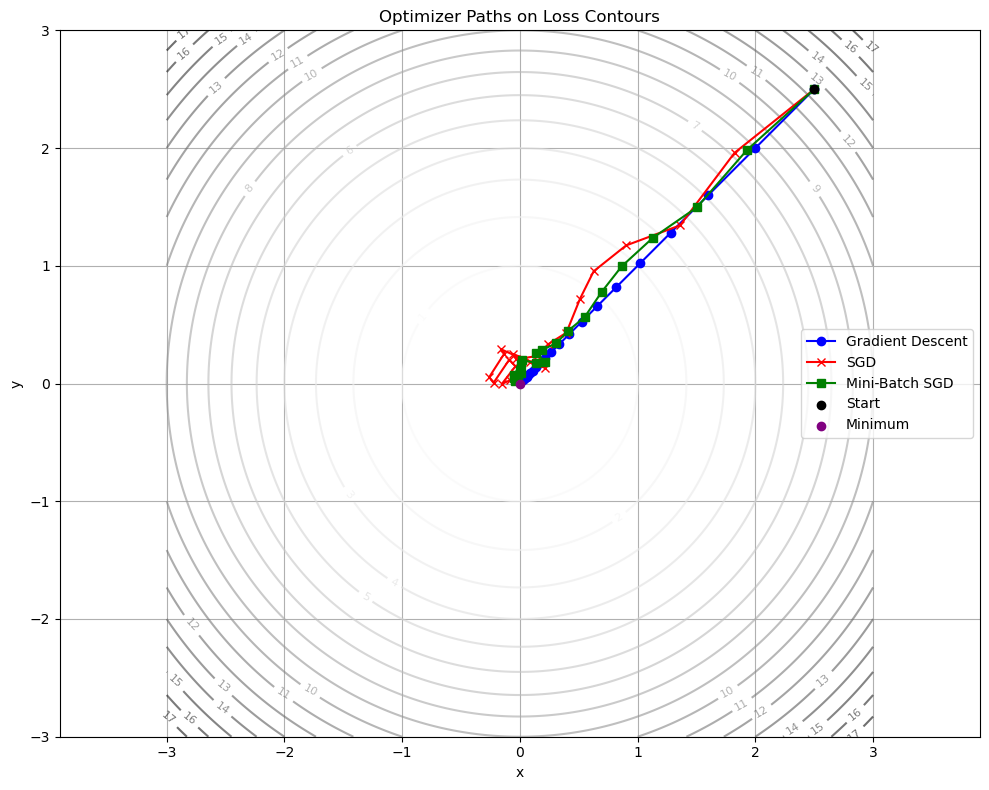

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Define the loss function and its gradient
def loss(x, y):
    return x**2 + y**2

def grad(x, y):
    return np.array([2*x, 2*y])

# Simulate optimizer paths
def simulate_optimizer(name, initial_pos, steps=20, lr=0.1, batch_noise=0.0, seed=0):
    np.random.seed(seed)
    pos = np.array(initial_pos, dtype=np.float32)
    path = [pos.copy()]
    
    for _ in range(steps):
        gradient = grad(*pos)
        if name in ['sgd', 'mini-batch']:
            noise = np.random.normal(0, batch_noise, size=2)
            gradient += noise
        pos = pos - lr * gradient
        path.append(pos.copy())
    
    return np.array(path)

# Simulate all three optimizers
gd_path = simulate_optimizer('gd', initial_pos=[2.5, 2.5], batch_noise=0.0)
sgd_path = simulate_optimizer('sgd', initial_pos=[2.5, 2.5], batch_noise=1.0)
mb_path  = simulate_optimizer('mini-batch', initial_pos=[2.5, 2.5], batch_noise=0.4)

# Plot contours and paths
x_vals = np.linspace(-3, 3, 400)
y_vals = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = loss(X, Y)

plt.figure(figsize=(10, 8))
cp = plt.contour(X, Y, Z, levels=20, cmap='Greys', alpha=0.6)
plt.clabel(cp, inline=True, fontsize=8)

plt.plot(gd_path[:,0], gd_path[:,1], marker='o', label="Gradient Descent", color='blue')
plt.plot(sgd_path[:,0], sgd_path[:,1], marker='x', label="SGD", color='red')
plt.plot(mb_path[:,0], mb_path[:,1], marker='s', label="Mini-Batch SGD", color='green')

# Start and end points
plt.scatter([2.5], [2.5], color='black', label='Start', zorder=5)
plt.scatter([0], [0], color='purple', label='Minimum', zorder=5)

plt.title("Optimizer Paths on Loss Contours")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()
